In [1]:
import pandas as pd
from arch import arch_model

ftse = pd.read_csv("ftse100_close_2015_2026.csv", parse_dates=["date"], index_col="date")["close"]
returns = ftse.pct_change().dropna() * 100
returns.shape

(2955,)

In [2]:
modelo_arch1 = arch_model(returns, mean="Constant", vol="ARCH", p=1)
resultado_arch1 = modelo_arch1.fit(disp="off")
print(resultado_arch1.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3794.29
Distribution:                  Normal   AIC:                           7594.58
Method:            Maximum Likelihood   BIC:                           7612.55
                                        No. Observations:                 2955
Date:                Wed, Sep 16 2026   Df Residuals:                     2954
Time:                        18:52:18   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0439  1.604e-02      2.735  6.232e-03 [1.

In [3]:
resultados = []
for p in range(1, 7):
    m = arch_model(returns, mean="Constant", vol="ARCH", p=p)
    r = m.fit(disp="off")
    resultados.append({"p": p, "log_likelihood": r.loglikelihood, "aic": r.aic, "bic": r.bic})

tabla = pd.DataFrame(resultados)
tabla

,p,log_likelihood,aic,bic
0,1,-3794.290364,7594.580728,7612.554489
1,2,-3737.188072,7482.376143,7506.341159
2,3,-3636.465278,7282.930557,7312.886826
3,4,-3603.663579,7219.327159,7255.274682
4,5,-3599.919358,7213.838716,7255.777493
5,6,-3591.216324,7198.432648,7246.362680


In [4]:
mejor_p = tabla.loc[tabla["aic"].idxmin(), "p"]
print("mejor p por AIC:", int(mejor_p))
print(tabla.to_string(index=False))

mejor p por AIC: 6
 p  log_likelihood         aic         bic
 1    -3794.290364 7594.580728 7612.554489
 2    -3737.188072 7482.376143 7506.341159
 3    -3636.465278 7282.930557 7312.886826
 4    -3603.663579 7219.327159 7255.274682
 5    -3599.919358 7213.838716 7255.777493
 6    -3591.216324 7198.432648 7246.362680


In [5]:
modelo_best = arch_model(returns, mean="Constant", vol="ARCH", p=int(mejor_p))
resultado_best = modelo_best.fit(disp="off")
print(resultado_best.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3591.22
Distribution:                  Normal   AIC:                           7198.43
Method:            Maximum Likelihood   BIC:                           7246.36
                                        No. Observations:                 2955
Date:                Wed, Sep 16 2026   Df Residuals:                     2954
Time:                        18:52:19   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0405  1.349e-02      2.999  2.707e-03 [1.

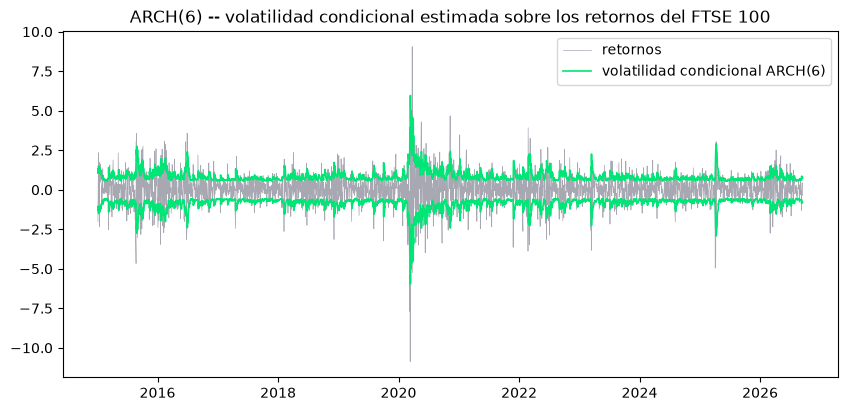

In [6]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

vol_condicional = resultado_best.conditional_volatility

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns.index, returns, color="#a8a8b3", linewidth=0.5, label="retornos")
ax.plot(vol_condicional.index, vol_condicional, color="#00e676", linewidth=1.2, label=f"volatilidad condicional ARCH({int(mejor_p)})")
ax.plot(vol_condicional.index, -vol_condicional, color="#00e676", linewidth=1.2)
ax.legend()
ax.set_title(f"ARCH({int(mejor_p)}) -- volatilidad condicional estimada sobre los retornos del FTSE 100")
plt.savefig("ftse-arch-volatilidad-condicional.png", dpi=150, bbox_inches="tight")
plt.show()